# Libraries and imports

In [1]:
import sys
from pathlib import Path
import time

sys.path.append(str(Path("../../build-release").resolve()))

import mpcd_cpp as mpcd

import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import poisson

## Solvent settings (Uniform positions and normal velocities at the beginning)

In [2]:
system = mpcd.System(
    25000,                         # N
    np.array([20, 20, 20]),        # box
    1.0,                           # a
    0.1,                           # h
    1.0,                           # m
    1.0,                           # kBT
    np.pi/6,                       # alpha
    14                             # generation seed
    )

system.initPositionsUniform()
system.initVelocitiesNormal()
system.removeDrift()

In [3]:
start = time.perf_counter()
solventSamples = mpcd.run_solvent(system, 1000, 1)
end = time.perf_counter()

print(f"Execution time: {end - start:.3f} s")

Execution time: 0.467 s


## Distributions

### 1-Cartesian component of velocity distribution

In [4]:
def velocityDistr(system):

    vx = system.v[:, 0]

    sigma = np.sqrt(system.kBT / system.m)

    x = np.linspace(vx.min(), vx.max(), 300)

    pdf = (
        1 / (np.sqrt(2 * np.pi) * sigma)
        * np.exp(-x**2 / (2 * sigma**2))
    )

    plt.hist(vx, bins=200, density=True, alpha=0.6, label="Simulation")
    plt.plot(x, pdf, label="Maxwell-Boltzmann")

    plt.xlabel(r"$v_x$")
    plt.ylabel(r"$P(v_x)$")
    plt.legend()
    plt.tight_layout()
    plt.show()

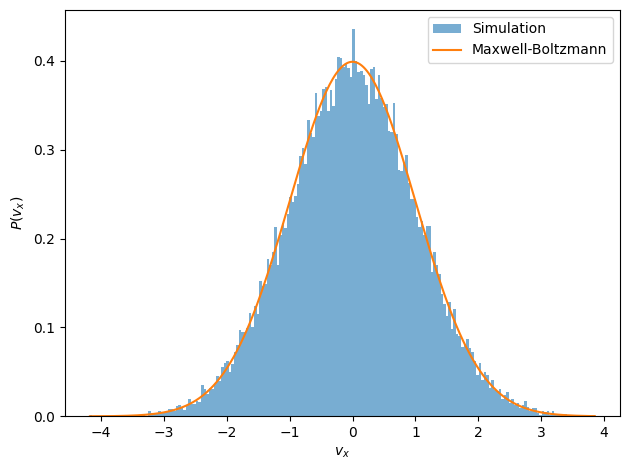

In [5]:
velocityDistr(system)

### Velocity Magnitude Distribution

In [6]:
def velocityMagnitudeDistr(system):

    v_abs = np.sqrt(np.sum(system.v**2, axis=1))

    sigma = np.sqrt(system.kBT / system.m)

    x = np.linspace(v_abs.min(), v_abs.max(), 300)

    pdf = (
        4*np.pi*(1/(2*np.pi*sigma)**(3.0/2))*x**2*np.exp(-x**2/(2*sigma))
    )
    # Since v_abs is a square, the actual values are roots
    plt.hist(v_abs, bins=200, density=True, alpha=0.6, label="Simulation")
    plt.plot(x, pdf, label="Maxwell-Boltzmann")

    plt.xlabel(r"$v_x$")
    plt.ylabel(r"$P(v_x)$")
    plt.legend()
    plt.tight_layout()
    plt.show()

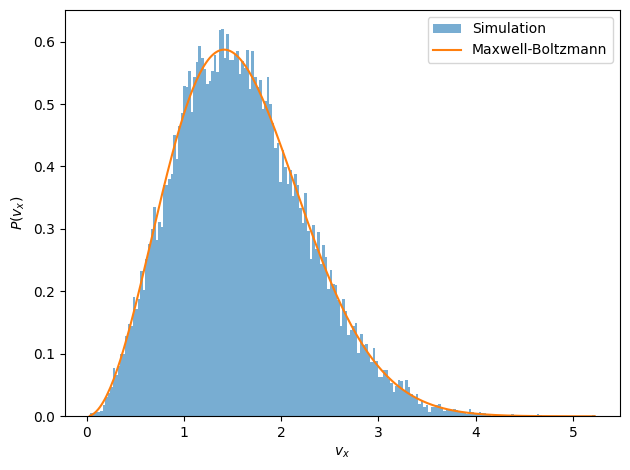

In [7]:
velocityMagnitudeDistr(system)

### Number of Particles in a Cell Distribution

In [8]:
def particlesInCellDistr(system):

    cells = mpcd.distributeToCells(system.r, system.box, system.a)
    nInCell = np.diff(np.asarray(cells.offsets))
    nMean = nInCell.mean()
    n_values = np.arange(0, nInCell.max() + 1)

    bin_edges = np.arange(
        nInCell.max() + 2
    ) - 0.5

    plt.figure(figsize=(7, 4))

    #print(nInCell[:20])
    #print(nInCell.max())

    plt.hist(
        nInCell,
        bins=bin_edges,
        density=True,
        alpha=0.6,
        label="Simulation"
    )

    plt.plot(
        n_values,
        poisson.pmf(n_values, nMean),
        "-",
        label=fr"Poisson, $\lambda={nMean:.2f}$"
    )

    plt.xlabel(r"Number of particles in a cell $N_c$")
    plt.ylabel(r"Probability $P(N_c)$")
    plt.title("Cell occupancy distribution")

    plt.legend()
    plt.tight_layout()
    plt.show()

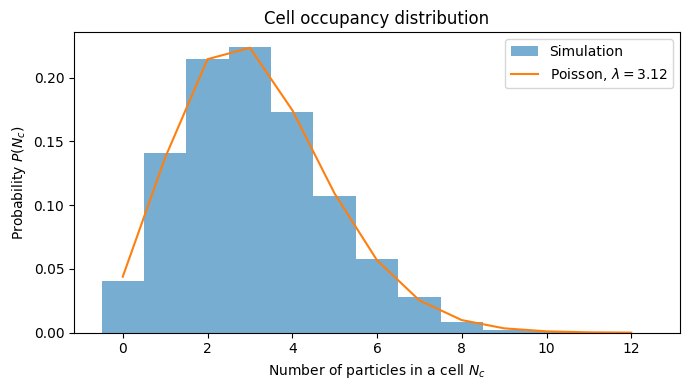

In [9]:
particlesInCellDistr(system)

In [10]:
cells = mpcd.distributeToCells(
    system.r,
    system.box,
    system.a
)

offsets = np.asarray(cells.offsets)
nInCell = np.diff(offsets)

print("len offsets:", len(offsets))
print("first 20 offsets:", offsets[:20])

print("min occupancy:", nInCell.min())
print("max occupancy:", nInCell.max())
print("mean occupancy:", nInCell.mean())
print("sum occupancy:", nInCell.sum())

print("monotonic:", np.all(offsets[1:] >= offsets[:-1]))
print("last offset:", offsets[-1])
print("N:", system.N)

len offsets: 8001
first 20 offsets: [ 0  4 10 11 13 16 22 24 29 33 36 39 40 44 49 52 62 63 66 66]
min occupancy: 0
max occupancy: 12
mean occupancy: 3.125
sum occupancy: 25000
monotonic: True
last offset: 25000
N: 25000


### Non-uniform positions

In [11]:
def plot_density_profile_x(system, title):
    counts, edges = np.histogram(
        system.r[:, 0],
        bins=40,
        range=(0, system.box[0])
    )

    centers = 0.5 * (edges[:-1] + edges[1:])

    plt.figure()
    plt.plot(centers, counts, marker="o")
    plt.xlabel("x")
    plt.ylabel("number of particles")
    plt.title(title)
    plt.show()

In [12]:
system.initPositionsUniformUpper()

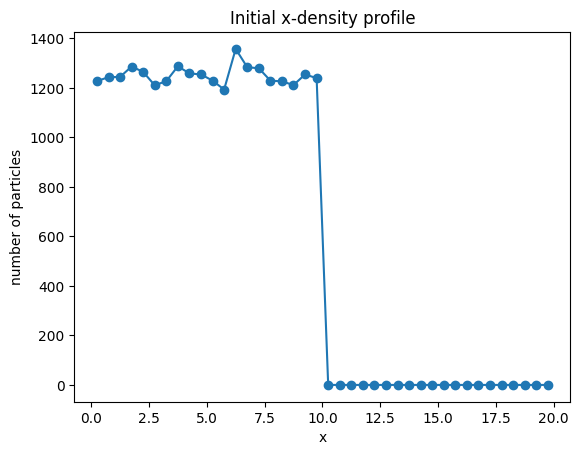

In [13]:
plot_density_profile_x(system, "Initial x-density profile")

In [14]:
solventSamples = mpcd.run_solvent(system, 50, 1)

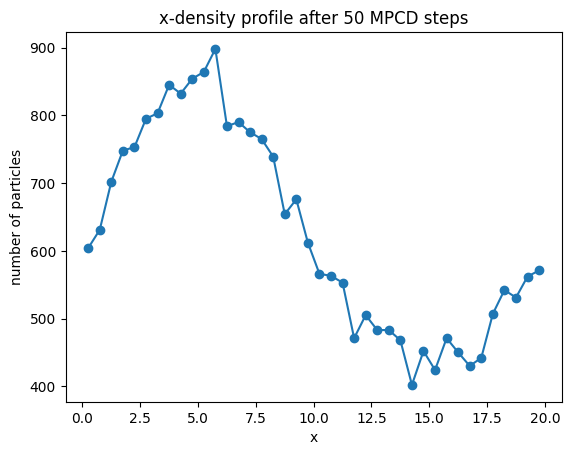

In [15]:
plot_density_profile_x(system, "x-density profile after 50 MPCD steps")

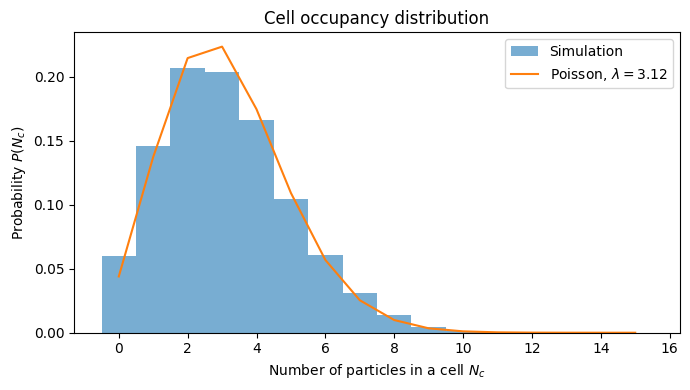

In [16]:
particlesInCellDistr(system)

In [17]:
print(len(solventSamples.kinetic_energy))
solventSamples += mpcd.run_solvent(system, 950, 1)
print(len(solventSamples.kinetic_energy))

50
1000


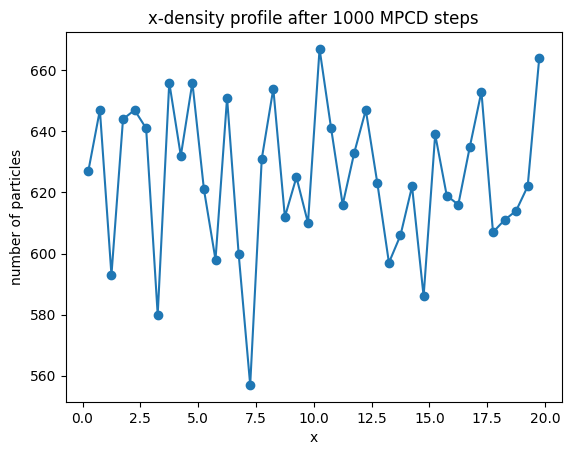

In [18]:
plot_density_profile_x(system, "x-density profile after 1000 MPCD steps")

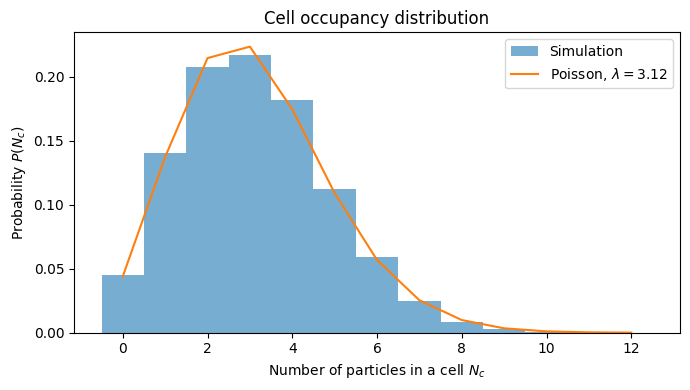

In [19]:
particlesInCellDistr(system)

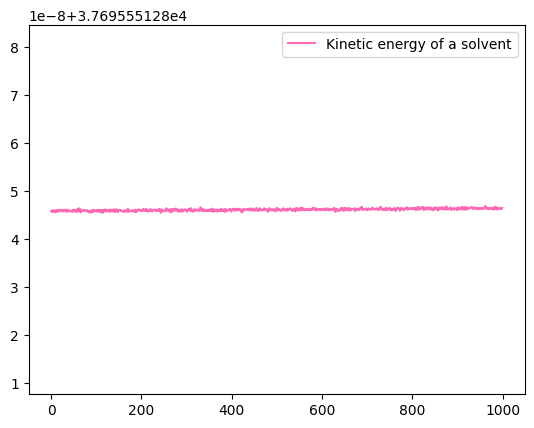

In [20]:
plt.figure()
plt.plot(solventSamples.kinetic_energy, color="hotpink", label="Kinetic energy of a solvent")
plt.legend()
plt.show()


### Non normal velocities

In [21]:
def plot_velocity_components(v, title):
    plt.figure()

    #plt.hist(v[:, 0], bins=60, density=True, alpha=0.5, label="vx")
    plt.hist(v[:, 1], bins=60, density=True, alpha=0.5, label="vy")
    #plt.hist(v[:, 2], bins=60, density=True, alpha=0.5, label="vz")

    plt.xlabel("velocity component")
    plt.ylabel("probability density")
    plt.title(title)
    plt.legend()
    plt.show()

In [22]:
system.initVelocitiesNonMaxwell()
system.removeDrift()

In [23]:
v_initial = system.v.copy()
speeds_initial = np.linalg.norm(system.v, axis=1)

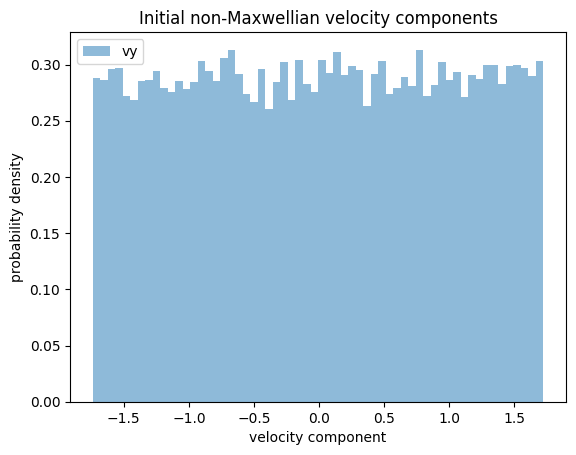

In [24]:
plot_velocity_components(v_initial, "Initial non-Maxwellian velocity components")

In [25]:
solventSamples = mpcd.run_solvent(system, 1000, 1)

In [26]:
v_finish = system.v.copy()
speeds_finish = np.linalg.norm(system.v, axis=1)

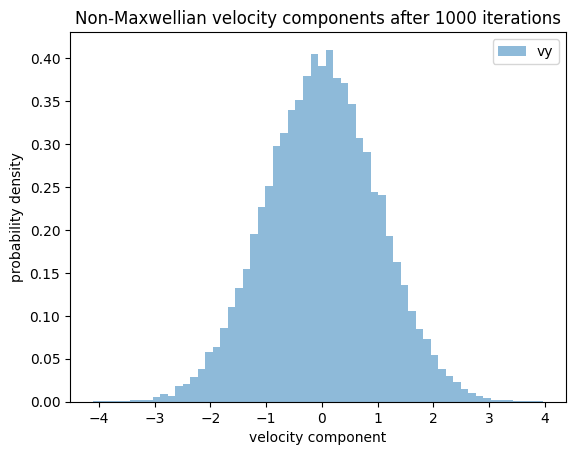

In [27]:
plot_velocity_components(v_finish, "Non-Maxwellian velocity components after 1000 iterations")

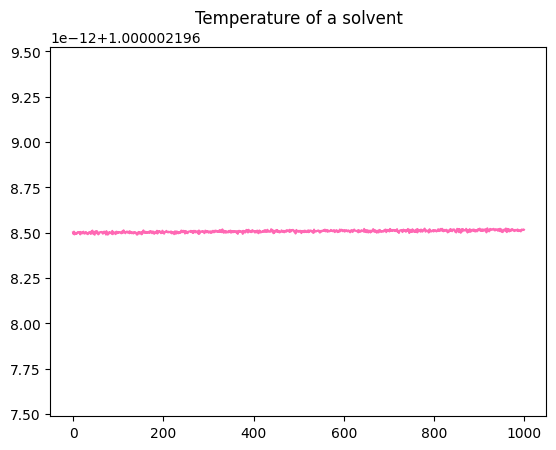

In [28]:
plt.figure()
plt.plot(solventSamples.temperature, color="hotpink")
plt.title("Temperature of a solvent")
plt.show()